# EdinburghAI: TinyML E-Nose

# Setup python environment

In [1]:
# Setup environment
%pip install pandas numpy matplotlib ai-edge-litert tensorflow seaborn

Note: you may need to restart the kernel to use updated packages.


# Load Data

In [ ]:
import pandas as pd
import os

NUM_CLASSES = 50

FEATURE_COLS = ["NO2", "C2H5OH", "VOC", "CO", "Alcohol", "LPG", "Benzene", "Temperature", "Pressure", "Humidity", "Gas_Resistance", "Altitude"]
TARGET_COL = "smell"

dfs = []
for folder in os.listdir("../data/smellnet/offline_training"):
    if '.' in folder: continue



    for file in os.listdir(f"../data/smellnet/offline_training/{folder}"):
        if not file.endswith(".csv"): continue

        df = pd.read_csv(f"../data/smellnet/offline_training/{folder}/{file}")
        df["smell"] = folder
        dfs.append(df)



training_data = pd.concat(dfs)

dfs = []
for folder in os.listdir("../data/smellnet/offline_testing"):
    if '.' in folder: continue

    for file in os.listdir(f"../data/smellnet/offline_testing/{folder}"):
        if not file.endswith(".csv"): continue

        df = pd.read_csv(f"../data/smellnet/offline_testing/{folder}/{file}")
        df["smell"] = folder
        dfs.append(df)


testing_data = pd.concat(dfs)

print(len(testing_data), " testing entries")
print(len(training_data), " training entries")

testing_data.head()

30007  testing entries
150711  training entries


,NO2,C2H5OH,VOC,CO,Alcohol,LPG,Benzene,Temperature,Pressure,Humidity,Gas_Resistance,Altitude,smell
0,215,309,472,826,3,31,4294967295,25.5,1022.89,28.11,81.75,-48.66,allspice
1,214,308,470,826,3,34,4294967295,25.5,1022.88,28.15,82.31,-48.66,allspice
2,213,307,469,825,3,34,4294967295,25.5,1022.88,28.18,82.80,-48.66,allspice
3,212,307,468,824,3,34,4294967295,25.5,1022.88,28.21,83.13,-48.74,allspice
4,211,305,466,824,3,34,4294967295,25.5,1022.89,28.24,83.87,-48.74,allspice


# Graph Data

In [40]:
# import matplotlib.pyplot as plt
# import seaborn as sns

# plt.figure(figsize=(8,6))

# datas = data.sample(n=1000)  # sample so it doesn't take 10 years
# sns.pairplot(datas[FEATURE_COLS+[TARGET_COL]], hue=TARGET_COL, palette='Set1', diag_kind='hist')
# plt.show()


# Train Neural Network

## Data Preprocessing

In [62]:
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler

x_train = training_data[FEATURE_COLS]
y_train = training_data[TARGET_COL]

x_test = testing_data[FEATURE_COLS]
y_test = testing_data[TARGET_COL]


label_encoder = LabelEncoder()

y_train_enc = label_encoder.fit_transform(y_train)
y_test_enc = label_encoder.transform(y_test)


x_train["Gas_Resistance"] = np.log1p(x_train["Gas_Resistance"])
x_test["Gas_Resistance"] = np.log1p(x_test["Gas_Resistance"])

scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

## Build model

In [93]:
from keras.models import Sequential
from keras.layers import Dense, Activation, Dropout, Input

model = Sequential()

model.add(Input(shape=(len(FEATURE_COLS),)))

model.add(Dense(32, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(32, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(NUM_CLASSES, activation='softmax'))

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 32)             │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 50)             │         1,650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,122 (12.20 KB)

 Trainable params: 3,122 (12.20 KB)

 Non-trainable params: 0 (0.00 B)

## Train Model

In [94]:
from keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    x_train,
    y_train_enc,
    validation_split=0.1,
    epochs=30,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/30
2120/2120 ━━━━━━━━━━━━━━━━━━━━ 3s 917us/step - accuracy: 0.4697 - loss: 1.6478 - val_accuracy: 0.0000e+00 - val_loss: 17.8605
Epoch 2/30
2120/2120 ━━━━━━━━━━━━━━━━━━━━ 2s 908us/step - accuracy: 0.6911 - loss: 0.8807 - val_accuracy: 0.0000e+00 - val_loss: 25.2758
Epoch 3/30
2120/2120 ━━━━━━━━━━━━━━━━━━━━ 2s 978us/step - accuracy: 0.7495 - loss: 0.7124 - val_accuracy: 0.0000e+00 - val_loss: 31.7597
Epoch 4/30
2120/2120 ━━━━━━━━━━━━━━━━━━━━ 2s 971us/step - accuracy: 0.7847 - loss: 0.6187 - val_accuracy: 0.0055 - val_loss: 38.9802
Epoch 5/30
2120/2120 ━━━━━━━━━━━━━━━━━━━━ 2s 865us/step - accuracy: 0.8049 - loss: 0.5641 - val_accuracy: 0.0000e+00 - val_loss: 46.3543
Epoch 6/30
2120/2120 ━━━━━━━━━━━━━━━━━━━━ 2s 868us/step - accuracy: 0.8234 - loss: 0.5159 - val_accuracy: 0.0047 - val_loss: 54.2868


## Graph the loss

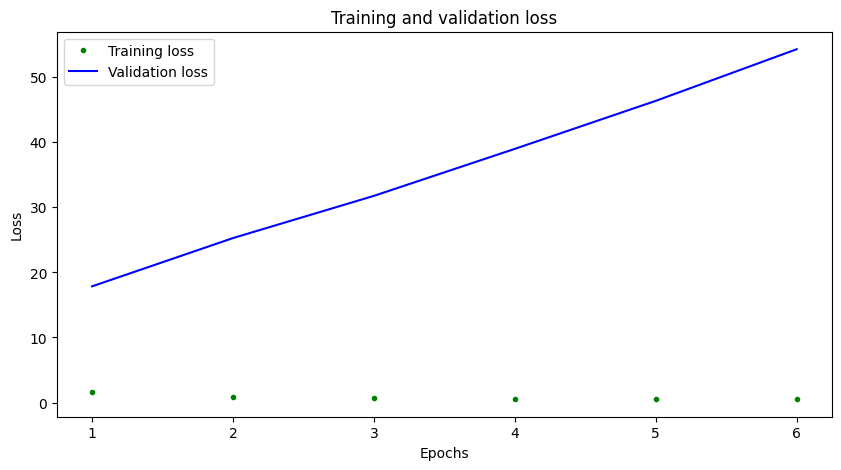

[10.0, 5.0]


In [95]:
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10,5)

loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'g.', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

print(plt.rcParams["figure.figsize"])

# Run with test data

In [96]:
import numpy as np

# get probability predictions
y_pred_probs = model.predict(x_test)

# convert to class indices
y_pred = y_pred_probs.argmax(axis=1)

938/938 ━━━━━━━━━━━━━━━━━━━━ 0s 485us/step


In [102]:
import pandas as pd

# get label names
labels = label_encoder.classes_

# create a dataframe for convenience
results_df = pd.DataFrame({
    "true": y_test_enc,
    "pred": y_pred
})

per_class_accuracy = []

for class_idx, class_name in enumerate(labels):
    # filter rows of this class
    class_rows = results_df[results_df["true"] == class_idx]

    if len(class_rows) == 0:
        acc = np.nan
    else:
        acc = (class_rows["pred"] == class_rows["true"]).mean()

    per_class_accuracy.append({
        "smell": class_name,
        "accuracy": acc,
        "count": len(class_rows)
    })

per_class_df = pd.DataFrame(per_class_accuracy)

print(per_class_df)

              smell  accuracy  count
0          allspice  1.000000    584
1            almond  1.000000    629
2          angelica  1.000000    657
3             apple  1.000000    606
4         asparagus  0.676420    581
5           avocado  1.000000    593
6            banana  0.996460    565
7        brazil_nut  0.932119    604
8          broccoli  0.890152    528
9   brussel_sprouts  0.305085    590
10          cabbage  0.432229    664
11           cashew  0.838063    599
12      cauliflower  0.893401    591
13        chamomile  0.962233    609
14          chervil  0.563123    602
15        chestnuts  0.936482    614
16           chives  0.531646    632
17         cinnamon  0.258232    577
18           cloves  0.762602    615
19        coriander  1.000000    604
20            cumin  0.769868    604
21             dill  1.000000    558
22           garlic  0.991749    606
23           ginger  1.000000    586
24         hazelnut  0.977853    587
25             kiwi  0.967857    560
2

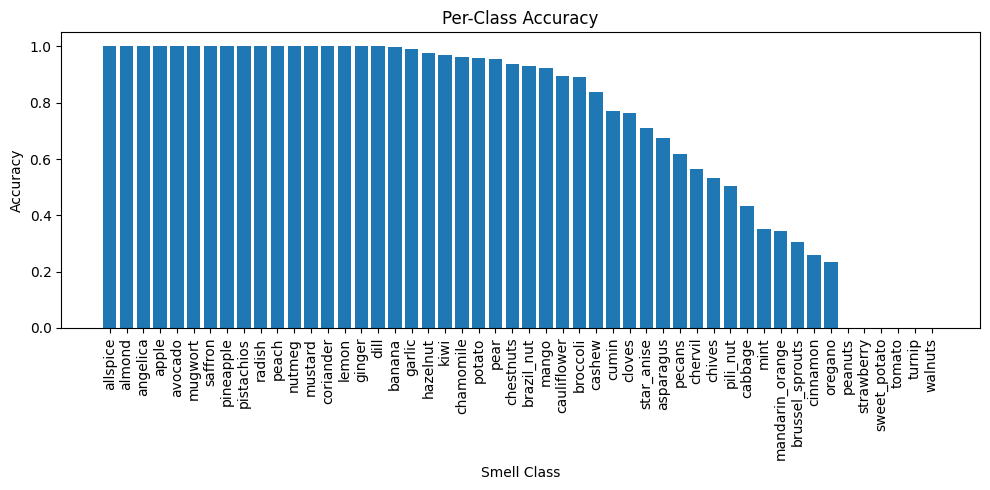

In [98]:
import matplotlib.pyplot as plt

# sort by accuracy for nicer plot
per_class_df = per_class_df.sort_values("accuracy", ascending=False)

plt.figure()
plt.bar(per_class_df["smell"], per_class_df["accuracy"])

plt.xticks(rotation=90)
plt.ylabel("Accuracy")
plt.xlabel("Smell Class")
plt.title("Per-Class Accuracy")
plt.tight_layout()

plt.show()

In [109]:
def predict_smell(row_values):
    import numpy as np
    import pandas as pd

    # Create DataFrame with correct column order
    row_df = pd.DataFrame([row_values], columns=FEATURE_COLS)

    # Apply same log transform used in training
    row_df["Gas_Resistance"] = np.log1p(row_df["Gas_Resistance"])

    # Scale using already-fitted scaler
    row_scaled = scaler.transform(row_df)

    # Predict probabilities
    probs = model.predict(row_scaled)

    # Convert to class index
    pred_class_index = probs.argmax(axis=1)

    # Convert to original smell label
    label = label_encoder.inverse_transform(pred_class_index)

    return label[0]

row = [33,58,50,751,2,10,0,24.69,1009.35,39.28,291.37,63.57]

print(predict_smell(row))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
mustard


# Convert to litert model

In [99]:
import tensorflow as tf
import os

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]  # quantization
tflite_model = converter.convert()

with open('model.tflite', 'wb') as f:
  f.write(tflite_model)

basic_model_size = os.path.getsize("model.tflite")
print("Model is %d bytes" % basic_model_size)

INFO:tensorflow:Assets written to: C:\Users\james\AppData\Local\Temp\tmpyxspy2cj\assets


INFO:tensorflow:Assets written to: C:\Users\james\AppData\Local\Temp\tmpyxspy2cj\assets


Saved artifact at 'C:\Users\james\AppData\Local\Temp\tmpyxspy2cj'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 12), dtype=tf.float32, name='keras_tensor_93')
Output Type:
  TensorSpec(shape=(None, 50), dtype=tf.float32, name=None)
Captures:
  1536860977488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1536860978640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1536860977872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1536860978256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1536860977680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1536256115152: TensorSpec(shape=(), dtype=tf.resource, name=None)
Model is 7808 bytes


## Test litert model

In [100]:
from ai_edge_litert.compiled_model import CompiledModel

model_lite = CompiledModel.from_file("model.tflite")

signature_index = 0

input_buffers = model_lite.create_input_buffers(signature_index)
output_buffers = model_lite.create_output_buffers(signature_index)


n_correct = 0

for i in range(len(x_test)):
    input_data = np.float32(x_test[i])
    input_buffers[0].write(input_data)

    model_lite.run_by_index(signature_index, input_buffers, output_buffers)
    output_array = output_buffers[0].read(NUM_CLASSES, np.float32)

    pred_class = int(np.argmax(output_array))
    true_class = int(y_test_enc[i])

    if pred_class == true_class:
        n_correct += 1

print("LiteRT accuracy:", n_correct / len(x_test))

LiteRT accuracy: 0.720731829239844


## Encode the model in an arduino header file

In [101]:
import os

os.system("""
echo "const unsigned char model[] = {" > /content/model.h
cat model.tflite | xxd -i      >> /content/model.h
echo "};"                              >> /content/model.h
""")

model_h_size = os.path.getsize("model.h")
print(f"Header file, model.h, is {model_h_size:,} bytes.")

Header file, model.h, is 23,278 bytes.
